# N1 · 装配检查 + mini-benchmark

> 配套 11.7-L1/L3 · capstone 的「亲手把全栈跑一遍」:
> ① **装配检查**: 一次 import M11 全栈 src, 证明组合成一个栈。
> ② **mini-benchmark**: 多种方法 (BC / mini-VLA / 世界模型MPC) 在同一 toy 控制任务比成功率
> (LIBERO/CALVIN 思路: 标准任务 + 成功率 + 可比)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import embodied_capstone as cap
cap.add_paths()   # 把 M11 全栈 src 加进 path
import numpy as np, torch

## 1. 装配检查: M11 全栈 import + 最小烟测

In [2]:
for label, ok, detail in cap.assembly_check():
    print(f"  [{'OK ' if ok else 'FAIL'}] {label:24} {detail}")
print("\n→ 全 7 个 src 都能 import + 跑通烟测 = 你掌握了完整具身栈。")

  [OK ] 11.1 toy_env             专家成功率 1.00
  [OK ] 11.1 action_serialize    9动作token, 离散损失0.02
  [OK ] 11.2 mini_vla            VLA backbone+动作头 build
  [OK ] 11.3 diffusion_policy    双峰绕障 demo (655, 2)
  [OK ] 11.4 bc_train            BC 策略 build
  [OK ] 11.5 world_model         随机转移 (100, 4)
  [OK ] 11.6 domain_rand         DR 配置随机化 demo

→ 全 7 个 src 都能 import + 跑通烟测 = 你掌握了完整具身栈。


## 2. mini-benchmark: 多方法在同一任务比成功率 (标准化评测)

In [3]:
torch.manual_seed(0)
import toy_env as env, mini_vla as vla, bc_train as bc, world_model as wm
S, A = env.make_demos(n=300, seed=0)
results = {}

# 方法1: BC (M11.4)
mbc = bc.build_bc_policy(); bc.train_bc(mbc, S, A, epochs=300)
results['BC (M11.4)'] = env.eval_policy(bc.bc_policy_fn(mbc), n_episodes=200)

# 方法2/3: mini-VLA 离散/连续 (M11.2)
for head in ['discrete', 'continuous']:
    m = vla.build_mini_vla(head=head); vla.train_vla(m, S, A, epochs=300)
    results[f'mini-VLA {head} (M11.2)'] = env.eval_policy(vla.make_policy(m), n_episodes=200)

# 方法4: 世界模型 + MPC (M11.5, 零专家! 用随机数据)
Sr, Ar, Dr = wm.make_random_transitions(n=3000, seed=0)
wmodel = wm.build_world_model(); wm.train_world_model(wmodel, Sr, Ar, Dr, epochs=400)
results['世界模型+MPC (M11.5)'] = env.eval_policy(wm.mpc_policy_fn(wmodel, n_samples=150, horizon=6), n_episodes=100)

print('mini-benchmark (2D 到达任务成功率):')
for k, v in results.items():
    print(f'  {k:26}: {v:.2f}')

mini-benchmark (2D 到达任务成功率):
  BC (M11.4)                : 0.97
  mini-VLA discrete (M11.2) : 1.00
  mini-VLA continuous (M11.2): 0.97
  世界模型+MPC (M11.5)          : 0.86


## 3. 可视化对比 (像 benchmark 排行榜)

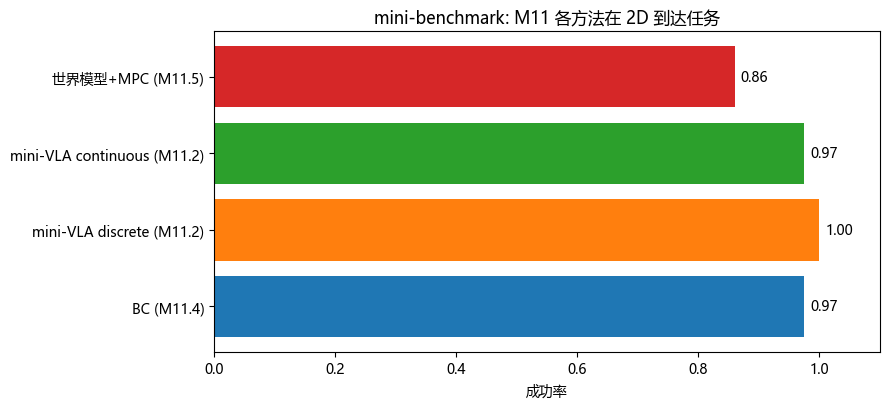

解读 (接 L3 评测):
  - BC / mini-VLA: 用专家 demo 监督学, 成功率高
  - 世界模型+MPC: 零专家 (随机数据) + 规划, 也能解 — 数据来源不同 (M11.5)
  - 成功率可比, 但要记: 它抓不全安全/平滑/泛化 (L3 评测的坑)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
names = list(results.keys()); vals = [results[k] for k in names]
fig, ax = plt.subplots(figsize=(9,4.2))
colors = ['C0','C1','C2','C3']
ax.barh(names, vals, color=colors[:len(names)])
for i,v in enumerate(vals): ax.text(v+0.01, i, f'{v:.2f}', va='center')
ax.set_xlim(0,1.1); ax.set_xlabel('成功率'); ax.set_title('mini-benchmark: M11 各方法在 2D 到达任务')
plt.tight_layout(); plt.show()
print('解读 (接 L3 评测):')
print('  - BC / mini-VLA: 用专家 demo 监督学, 成功率高')
print('  - 世界模型+MPC: 零专家 (随机数据) + 规划, 也能解 — 数据来源不同 (M11.5)')
print('  - 成功率可比, 但要记: 它抓不全安全/平滑/泛化 (L3 评测的坑)')

## 4. 反思
你跑了 M11 全栈 + 一个 mini-benchmark。带走:
- **装配**: 7 个 src 组合成完整具身栈 — 你掌握的是体系不是碎片。
- **多方法可比**: BC / mini-VLA / 世界模型MPC 在同一任务比成功率 (LIBERO/CALVIN 思路)。
- **评测要深**: 成功率必要不充分; 真评要看分层泛化 + 鲁棒性 + sim2real (L3)。
下一步 N2: 从「会用」到「能推进」— 产出具身研究 idea 卡。